In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\images\short\shortphosphorescence_5.jpg")

In [21]:
blue_channel = img[:, :, 0]

In [22]:
# Mask areas that are more "blue" than red or green
blue_mask = (img[:, :, 0] > 100) & (img[:, :, 0] > img[:, :, 1] + 20) & (img[:, :, 0] > img[:, :, 2] + 20)
blue_only = np.zeros_like(blue_channel)
blue_only[blue_mask] = blue_channel[blue_mask]


In [23]:
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)


In [ ]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()
for cnt in contours:
    if cv2.contourArea(cnt) > 10:  # filter noise
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)  #blue box



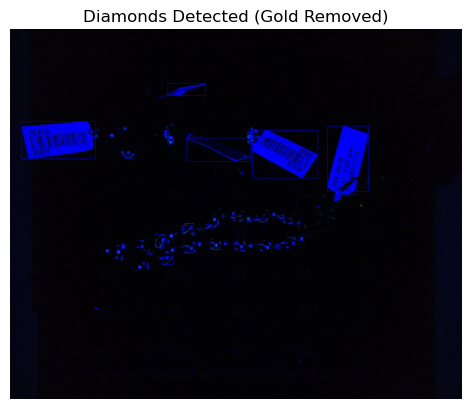

In [25]:
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Diamonds Detected (Gold Removed)')
plt.axis('off')
plt.show()


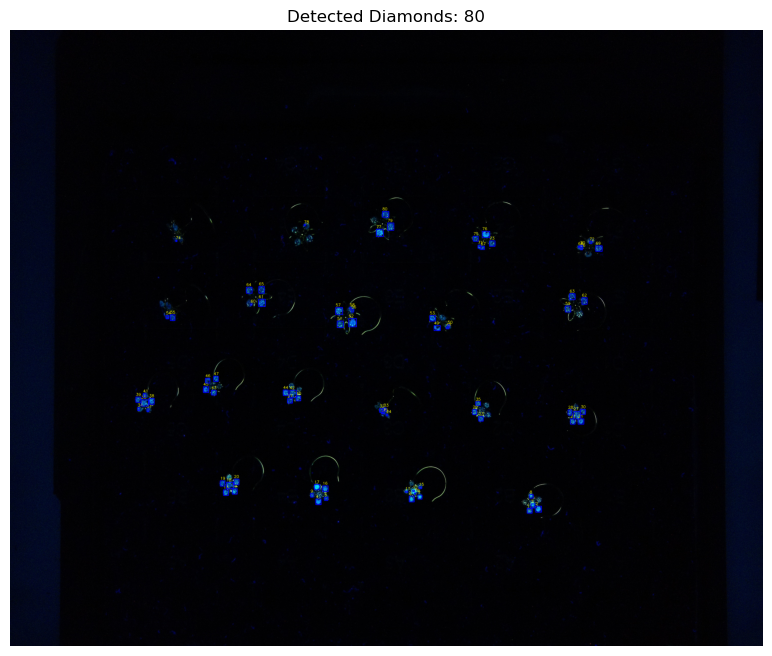

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\479_184805_230224-20250717T064456Z-1-001\479_184805_230224\shortphosphorescence.jpg")

#Extract RGB channels
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

#Mask regions where blue is dominant
blue_mask = (blue > 100) & (blue > green + 20) & (blue > red + 20)
blue_only = np.zeros_like(blue)
blue_only[blue_mask] = blue[blue_mask]

#Threshold the blue-only image
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)

#Clean up small noise using morphological operations
kernel = np.ones((3, 3), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#Find contours
contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Filter small contours (noise)
min_contour_area = 10  # Change based on size of diamond glow
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

#Annotate image with bounding boxes and labels
output_img = img.copy()
for idx, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box
    cv2.putText(output_img, str(idx + 1), (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

#result
output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.title(f'Detected Diamonds: {len(filtered_contours)}')
plt.axis('off')
plt.show()


In [ ]:
# Save the high-resolution annotated image
cv2.imwrite('annotateddiamonds.jpg', output_img)

Saved as: annotated_diamonds.jpg


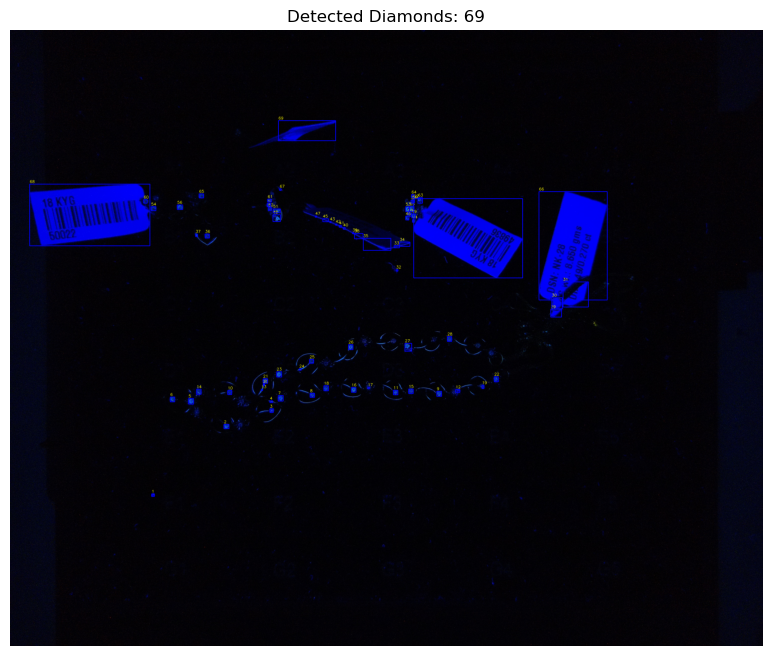

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"C:\Users\febaj\Downloads\Diamond\images\short\shortphosphorescence_5.jpg")

# Extract RGB channels
blue = img[:, :, 0]
green = img[:, :, 1]
red = img[:, :, 2]

#Mask regions where blue is dominant
blue_mask = (blue > 100) & (blue > green + 20) & (blue > red + 20)
blue_only = np.zeros_like(blue)
blue_only[blue_mask] = blue[blue_mask]

#Threshold the blue-only image
_, thresh = cv2.threshold(blue_only, 60, 255, cv2.THRESH_BINARY)

#Clean up small noise using morphological operations
kernel = np.ones((3, 3), np.uint8)
thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#Find contours
contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Filter small contours (noise)
min_contour_area = 10  # Change based on size of diamond glow
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

#Annotate image with bounding boxes and labels
output_img = img.copy()
for idx, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box
    cv2.putText(output_img, str(idx + 1), (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)

output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.title(f'Detected Diamonds: {len(filtered_contours)}')
plt.axis('off')
plt.show()
